# Student Academic Data Preprocessing and Exploratory Analysis Using Python

### AI Internship Project

**Objective:**  
To understand and apply fundamental data preprocessing and exploratory
data analysis techniques using Python.

## 1. Project Objective

The objective of this project is to demonstrate a basic machine learning
data preprocessing workflow using Python.

The project focuses on:

- Loading and inspecting a dataset
- Understanding dataset structure and data types
- Identifying and handling missing values
- Detecting and removing duplicate records
- Encoding categorical variables
- Selecting relevant features
- Scaling numerical features
- Performing exploratory data analysis (EDA)
- Documenting the preprocessing steps

## 2. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

## 3. Create the Student Dataset

A small student academic dataset is created for demonstrating
data preprocessing and exploratory analysis techniques.

In [2]:
data = {
    "Student_ID": ["ST001", "ST002", "ST003", "ST004", "ST005"],
    "Student": [
        "Aarav Mehta",
        "Riya Sharma",
        "Kabir Patel",
        "Ananya Singh",
        "Arjun Verma"
    ],
    "Program": [
        "Creative Arts",
        "Liberal Arts",
        "Science",
        "Science",
        "Creative Arts"
    ],
    "Status": [
        "Active",
        "Active",
        "Active",
        "Inactive",
        "Active"
    ],
    "Age": [20, 21, 19, 22, 20],
    "Gender": ["Male", "Female", "Male", "Female", "Male"],
    "Year": [2, 3, 1, 4, 2],
    "Attendance": [87, 92, 78, 65, 95],
    "Study_Hours": [12, 15, 8, 6, 14],
    "Exam_Score": [82, 91, 74, 61, 88]
}

raw_df = pd.DataFrame(data)

raw_df

,Student_ID,Student,Program,Status,Age,Gender,Year,Attendance,Study_Hours,Exam_Score
0,ST001,Aarav Mehta,Creative Arts,Active,20,Male,2,87,12,82
1,ST002,Riya Sharma,Liberal Arts,Active,21,Female,3,92,15,91
2,ST003,Kabir Patel,Science,Active,19,Male,1,78,8,74
3,ST004,Ananya Singh,Science,Inactive,22,Female,4,65,6,61
4,ST005,Arjun Verma,Creative Arts,Active,20,Male,2,95,14,88


## 4. Initial Data Inspection

The dataset is inspected to understand its dimensions, columns,
data types, and basic numerical statistics.

In [3]:
raw_df.head()

,Student_ID,Student,Program,Status,Age,Gender,Year,Attendance,Study_Hours,Exam_Score
0,ST001,Aarav Mehta,Creative Arts,Active,20,Male,2,87,12,82
1,ST002,Riya Sharma,Liberal Arts,Active,21,Female,3,92,15,91
2,ST003,Kabir Patel,Science,Active,19,Male,1,78,8,74
3,ST004,Ananya Singh,Science,Inactive,22,Female,4,65,6,61
4,ST005,Arjun Verma,Creative Arts,Active,20,Male,2,95,14,88


In [4]:
raw_df.shape

(5, 10)

In [5]:
raw_df.columns

Index(['Student_ID', 'Student', 'Program', 'Status', 'Age', 'Gender', 'Year',
       'Attendance', 'Study_Hours', 'Exam_Score'],
      dtype='object')

In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Student_ID   5 non-null      object
 1   Student      5 non-null      object
 2   Program      5 non-null      object
 3   Status       5 non-null      object
 4   Age          5 non-null      int64 
 5   Gender       5 non-null      object
 6   Year         5 non-null      int64 
 7   Attendance   5 non-null      int64 
 8   Study_Hours  5 non-null      int64 
 9   Exam_Score   5 non-null      int64 
dtypes: int64(5), object(5)
memory usage: 532.0+ bytes


In [7]:
raw_df.describe()

,Age,Year,Attendance,Study_Hours,Exam_Score
count,5.000000,5.000000,5.000000,5.000000,5.000000
mean,20.400000,2.400000,83.400000,11.000000,79.200000
std,1.140175,1.140175,12.136721,3.872983,12.070626
min,19.000000,1.000000,65.000000,6.000000,61.000000
25%,20.000000,2.000000,78.000000,8.000000,74.000000
50%,20.000000,2.000000,87.000000,12.000000,82.000000
75%,21.000000,3.000000,92.000000,14.000000,88.000000
max,22.000000,4.000000,95.000000,15.000000,91.000000


## 5. Introduce Missing Values

To demonstrate missing-value handling, missing observations are
introduced into selected numerical columns.

In [8]:
clean_df = raw_df.copy()

clean_df.loc[1, "Age"] = np.nan
clean_df.loc[3, "Exam_Score"] = np.nan
clean_df.loc[4, "Attendance"] = np.nan

clean_df

,Student_ID,Student,Program,Status,Age,Gender,Year,Attendance,Study_Hours,Exam_Score
0,ST001,Aarav Mehta,Creative Arts,Active,20.0,Male,2,87.0,12,82.0
1,ST002,Riya Sharma,Liberal Arts,Active,NaN,Female,3,92.0,15,91.0
2,ST003,Kabir Patel,Science,Active,19.0,Male,1,78.0,8,74.0
3,ST004,Ananya Singh,Science,Inactive,22.0,Female,4,65.0,6,NaN
4,ST005,Arjun Verma,Creative Arts,Active,20.0,Male,2,NaN,14,88.0


## 6. Missing Value Analysis

The number of missing values in each column is identified using
`isnull().sum()`.

In [9]:
clean_df.isnull().sum()

,0
Student_ID,0
Student,0
Program,0
Status,0
Age,1
Gender,0
Year,0
Attendance,1
Study_Hours,0
Exam_Score,1


### Missing Value Treatment

Missing values in the numerical columns are replaced using the
median of each respective column.

Median imputation is used because it is less sensitive to extreme
values than mean imputation.

In [10]:
clean_df["Age"] = clean_df["Age"].fillna(
    clean_df["Age"].median()
)

clean_df["Attendance"] = clean_df["Attendance"].fillna(
    clean_df["Attendance"].median()
)

clean_df["Exam_Score"] = clean_df["Exam_Score"].fillna(
    clean_df["Exam_Score"].median()
)

In [11]:
clean_df.isnull().sum()

,0
Student_ID,0
Student,0
Program,0
Status,0
Age,0
Gender,0
Year,0
Attendance,0
Study_Hours,0
Exam_Score,0


## 7. Duplicate Detection and Removal

Duplicate records are identified and removed to prevent repeated
observations from affecting the analysis.

In [12]:
# Demonstrate duplicate detection
clean_df = pd.concat(
    [clean_df, clean_df.iloc[[2]]],
    ignore_index=True
)

print("Duplicate rows before removal:")
print(clean_df.duplicated().sum())

Duplicate rows before removal:
1


In [13]:
clean_df = clean_df.drop_duplicates()

print("Duplicate rows after removal:")
print(clean_df.duplicated().sum())

Duplicate rows after removal:
0


## 8. Data Type Inspection

The data types of the columns are checked to ensure that numerical
and categorical variables are appropriately represented.

In [14]:
clean_df.dtypes

,0
Student_ID,object
Student,object
Program,object
Status,object
Age,float64
Gender,object
Year,int64
Attendance,float64
Study_Hours,int64
Exam_Score,float64


## 9. Categorical Variable Analysis

The categorical variables are examined before encoding.

In [15]:
clean_df["Program"].value_counts()

,count
Program,
Creative Arts,2
Science,2
Liberal Arts,1


In [16]:
clean_df["Gender"].value_counts()

,count
Gender,
Male,3
Female,2


In [17]:
clean_df["Status"].value_counts()

,count
Status,
Active,4
Inactive,1


## 10. Categorical Encoding

Categorical variables cannot be directly used by many machine-learning
algorithms. Therefore, Program, Gender, and Status are converted into
numerical representations using one-hot encoding.

`drop_first=True` is used to remove one reference category and avoid
redundant dummy variables.

In [18]:
encoded_df = clean_df.copy()

encoded_df = pd.get_dummies(
    encoded_df,
    columns=["Program", "Gender", "Status"],
    drop_first=True
)

encoded_df.head()

,Student_ID,Student,Age,Year,Attendance,Study_Hours,Exam_Score,Program_Liberal Arts,Program_Science,Gender_Male,Status_Inactive
0,ST001,Aarav Mehta,20.0,2,87.0,12,82.0,False,False,True,False
1,ST002,Riya Sharma,20.0,3,92.0,15,91.0,True,False,False,False
2,ST003,Kabir Patel,19.0,1,78.0,8,74.0,False,True,True,False
3,ST004,Ananya Singh,22.0,4,65.0,6,85.0,False,True,False,True
4,ST005,Arjun Verma,20.0,2,82.5,14,88.0,False,False,True,False


In [19]:
encoded_df.columns

Index(['Student_ID', 'Student', 'Age', 'Year', 'Attendance', 'Study_Hours',
       'Exam_Score', 'Program_Liberal Arts', 'Program_Science', 'Gender_Male',
       'Status_Inactive'],
      dtype='object')

## 11. Feature Selection

Student ID and Student Name are identifier fields rather than
meaningful predictive features, so they are excluded from the
potential machine-learning feature set.

Exam Score is separated as the target variable for a hypothetical
prediction task.

In [20]:
encoded_df = encoded_df.drop(
    columns=["Student_ID", "Student"]
)

X = encoded_df.drop(
    columns=["Exam_Score"]
)

y = encoded_df["Exam_Score"]

## 12. Numerical Feature Scaling

Numerical features are standardized using `StandardScaler`.

The numerical variables are transformed so that they are on a
comparable standardized scale.

One-hot encoded categorical variables are not scaled.

In [21]:
scaler = StandardScaler()

numeric_features = [
    "Age",
    "Year",
    "Attendance",
    "Study_Hours"
]

X[numeric_features] = scaler.fit_transform(
    X[numeric_features]
)

X.head()

,Age,Year,Attendance,Study_Hours,Program_Liberal Arts,Program_Science,Gender_Male,Status_Inactive
0,-0.204124,-0.392232,0.662261,0.288675,False,False,True,False
1,-0.204124,0.588348,1.205099,1.154701,True,False,False,False
2,-1.224745,-1.372813,-0.314846,-0.866025,False,True,True,False
3,1.837117,1.568929,-1.726223,-1.443376,False,True,False,True
4,-0.204124,-0.392232,0.173708,0.866025,False,False,True,False


# 13. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the
distribution and relationships within the student dataset.

### 13.1 Distribution of Exam Scores

A histogram is used to visualize the distribution of student
exam scores.

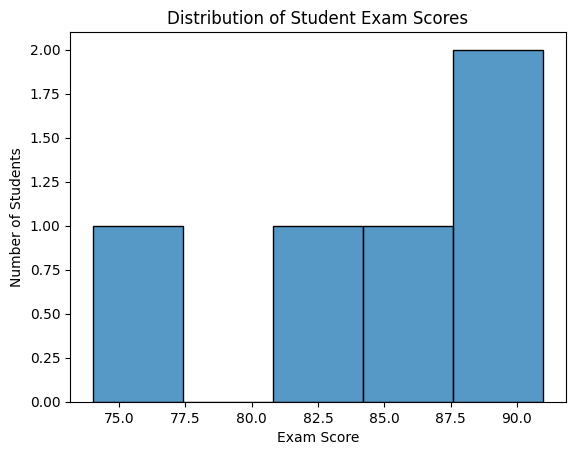

In [22]:
sns.histplot(
    data=clean_df,
    x="Exam_Score",
    bins=5
)

plt.title("Distribution of Student Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()

### 13.2 Attendance vs Exam Score

A scatter plot is used to examine the relationship between
student attendance and exam scores.

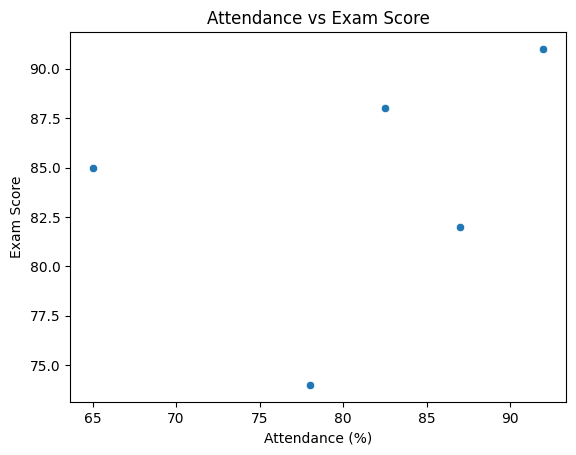

In [23]:
sns.scatterplot(
    data=clean_df,
    x="Attendance",
    y="Exam_Score"
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")
plt.show()

### 13.3 Correlation Analysis

Correlation is calculated to measure the linear relationship
between attendance and exam score.

In [24]:
correlation = clean_df[
    "Attendance"
].corr(
    clean_df["Exam_Score"]
)

print("Attendance vs Exam Score correlation:", correlation)

Attendance vs Exam Score correlation: 0.3165258129878196


The correlation is approximately 0.32, indicating a weak positive
linear relationship in this small sample. The scatter plot also
shows that the observations are relatively scattered.

### 13.4 Average Exam Score by Program

The average exam score is calculated for each academic program
to provide a descriptive comparison across programs.

In [25]:
program_scores = clean_df.groupby(
    "Program"
)["Exam_Score"].mean()

program_scores

,Exam_Score
Program,
Creative Arts,85.0
Liberal Arts,91.0
Science,79.5


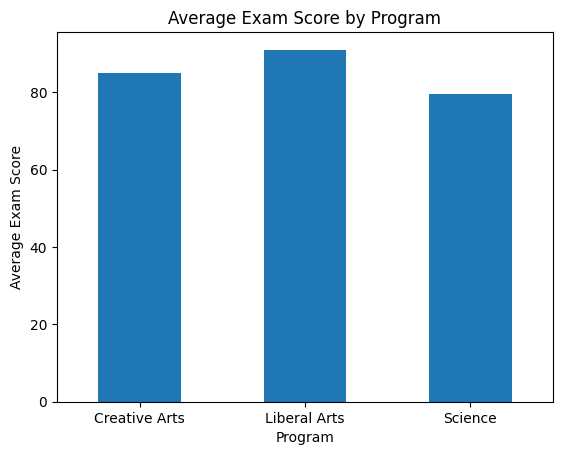

In [26]:
program_scores.plot(kind="bar")

plt.title("Average Exam Score by Program")
plt.xlabel("Program")
plt.ylabel("Average Exam Score")
plt.xticks(rotation=0)
plt.show()

### 13.5 Attendance Analysis

Descriptive statistics and a histogram are used to understand
the distribution of student attendance.

In [27]:
clean_df["Attendance"].describe()

,Attendance
count,5.000000
mean,80.900000
std,10.298058
min,65.000000
25%,78.000000
50%,82.500000
75%,87.000000
max,92.000000


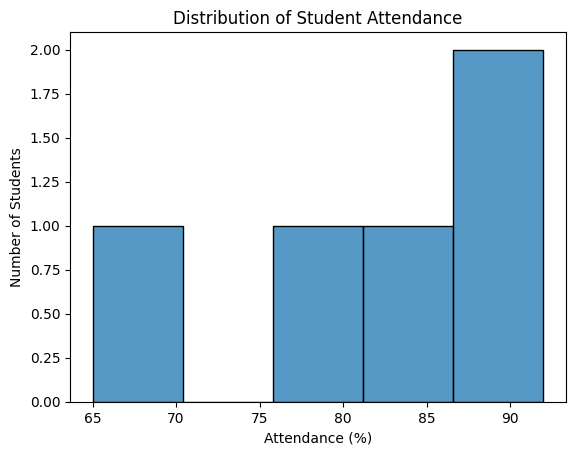

In [28]:
sns.histplot(
    data=clean_df,
    x="Attendance",
    bins=5
)

plt.title("Distribution of Student Attendance")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Students")
plt.show()

# 14. Final Dataset Verification

The final cleaned dataset is checked to ensure that missing values
and duplicate records have been successfully handled.

In [29]:
final_df = clean_df.copy()

print("Missing values:")
print(final_df.isnull().sum())

print("\nDuplicate rows:")
print(final_df.duplicated().sum())

print("\nDataset shape:")
print(final_df.shape)

Missing values:
Student_ID     0
Student        0
Program        0
Status         0
Age            0
Gender         0
Year           0
Attendance     0
Study_Hours    0
Exam_Score     0
dtype: int64

Duplicate rows:
0

Dataset shape:
(5, 10)


## Final Clean Dataset

The final dataset contains the cleaned student records after
missing-value treatment and duplicate removal.

In [30]:
final_df

,Student_ID,Student,Program,Status,Age,Gender,Year,Attendance,Study_Hours,Exam_Score
0,ST001,Aarav Mehta,Creative Arts,Active,20.0,Male,2,87.0,12,82.0
1,ST002,Riya Sharma,Liberal Arts,Active,20.0,Female,3,92.0,15,91.0
2,ST003,Kabir Patel,Science,Active,19.0,Male,1,78.0,8,74.0
3,ST004,Ananya Singh,Science,Inactive,22.0,Female,4,65.0,6,85.0
4,ST005,Arjun Verma,Creative Arts,Active,20.0,Male,2,82.5,14,88.0


# 15. Conclusion

This project demonstrated a complete basic data preprocessing and
exploratory data analysis workflow using Python.

The student dataset was inspected to understand its structure,
dimensions, data types, and numerical characteristics.

Missing values were identified and handled using median imputation,
while duplicate records were detected and removed.

Categorical variables were converted into numerical representations
using one-hot encoding. Identifier columns were excluded from the
potential machine-learning feature set, and numerical features were
standardized using StandardScaler.

Exploratory Data Analysis was performed using descriptive statistics,
histograms, scatter plots, correlation analysis, and program-wise
comparisons.

After preprocessing, the final dataset contained 5 records and
10 columns, with no missing values or duplicate records.

This project demonstrates the importance of cleaning, transforming,
and understanding data before applying machine-learning algorithms.